# Whole Brain Analysis

This notebook performs comprehensive whole-brain analysis of neural responses to olfactory stimuli.

**Analysis Sections:**
1. Load forebrain and hindbrain data
2. Per-area mean trace plotting
3. Positive vs negative stimuli comparison
4. Valence neuron subset analysis
5. Grand average population traces
6. Raster plot visualization (paper figure)
7. PCA trajectory analysis (2D, 3D, timecourse)

## 1. Configuration and Parameters

In [6]:
# ============================================================================
# FILE PATHS - Modify these for your system
# ============================================================================

# Input files
FOREBRAIN_DATA_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_fb_fish_dfs_final.h5'
HINDBRAIN_DATA_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_hb_fish_dfs_final.h5'

# Subset neurons e.g. Valence neuron correlation files
NEGATIVE_CORRELATION_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_negative_correlations_25s_no_HCl_1000_corrected.csv'
POSITIVE_CORRELATION_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_positive_correlations_25s_no_HCl_1000_corrected.csv'

# Output directory for figures (CHANGE THIS TO YOUR PATH!)
FIGURE_OUTPUT_DIR = '/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/'

In [1]:
# ============================================================================
# ANALYSIS PARAMETERS
# ============================================================================

# Main stimuli for analysis
KEY_STIMULI = ['ade', 'cad_2.5mm', 'kw', 'fex_1', 'qui_2.5mm', 'pro_2.5mm', 'ph4.5']

# Stimulus colors (matching order of KEY_STIMULI)
STIMULUS_COLORS = ['plum', 'mediumorchid', 'forestgreen', 'limegreen', 'deeppink', 'olive', 'fuchsia']

# Valence groupings
POSITIVE_STIMULI = ['fex_1', 'kw', 'pro_2.5mM']
NEGATIVE_STIMULI = ['ade', 'cad_2.5mM', 'ph4.5', 'qui_2.5mM']

# Trace analysis parameters
SAMPLING_FREQUENCY = 3  # Hz (frames per second)
TIME_INTERVAL = 1 / SAMPLING_FREQUENCY  # Seconds per frame
SMOOTHING_SIGMA = 2  # Gaussian filter sigma
START_TIME = 35  # Plot only after this time (seconds)

# Stimulus timing (for grand average plot)
STIMULUS_START_TIME = 53  # seconds
STIMULUS_END_TIME = 63  # seconds

# Data structure
TRIALS_PER_NEURON = 45  # Used for neuron count calculations

# Valence neuron filtering
VALENCE_P_THRESHOLD = 0.05  # FDR-corrected p-value threshold

# Raster plot parameters
RASTER_STIMULUS_ORDER = ['fex_1', 'kw', 'pro_2.5mM', 'ade', 'cad_2.5mM', 'ph4.5', 'qui_2.5mM']
RASTER_START_FRAME = 60  # Start plotting from this frame
RASTER_RESPONSE_THRESHOLD = 0.5  # Minimum max response for inclusion
RASTER_N_NEURONS = 100  # Number of neurons to randomly sample
RASTER_RANDOM_STATE = 42  # For reproducibility

# PCA parameters
PCA_N_COMPONENTS = 10  # Number of PCs to compute
PCA_SMOOTHING_SIGMA = 2  # Gaussian smoothing for PC trajectories

In [2]:
# ============================================================================
# STIMULUS LABEL MAPPINGS
# ============================================================================

# Main labels (with corrected mM notation)
STIMULUS_LABELS = {
    'ade': 'Ade',
    'cad_2.5mm': 'Cad',
    'kw': 'KW',
    'fex_1': 'Fex',
    'qui_2.5mm': 'Qui',
    'pro_2.5mm': 'Pro',
    'ph4.5': 'pH 4.5',
    # Additional mappings for concentration series and raster plot
    'fex_2': 'Fex 1:100',
    'fex_3': 'Fex 1:1000',
    'cad_2.5mM': 'Cad 2.5mM',
    'cad_250um': 'Cad 250µM',
    'cad_25um': 'Cad 25µM',
    'pro_2.5mM': 'Pro 2.5mM',
    'pro_250um': 'Pro 250µM',
    'pro_25um': 'Pro 25µM',
    'qui_2.5mM': 'Qui 2.5mM',
    'qui_250um': 'Qun 250µM',
    'qui_25um': 'Qui 25µM'
}

# Create color map
COLOR_MAP = dict(zip(KEY_STIMULI, STIMULUS_COLORS))

# ============================================================================
# ALTERNATIVE COLOR SCHEMES (for concentration series)
# ============================================================================
# Uncomment and modify KEY_STIMULI above to use these for concentration series

# Quinine concentration series
# STIMULUS_COLORS = ['deeppink', 'palevioletred', 'pink']
# KEY_STIMULI = ['qui_2.5mm', 'qui_250um', 'qui_25um']

# Cadaverine concentration series  
# STIMULUS_COLORS = ['mediumorchid', 'violet', 'plum']
# KEY_STIMULI = ['cad_2.5mm', 'cad_250um', 'cad_25um']

# Proline concentration series
# STIMULUS_COLORS = ['olive', 'olivedrab', 'yellowgreen']
# KEY_STIMULI = ['pro_2.5mm', 'pro_250um', 'pro_25um']

# Food extract concentration series
# STIMULUS_COLORS = ['limegreen', 'seagreen', 'springgreen']
# KEY_STIMULI = ['fex_1', 'fex_2', 'fex_3']

## 2. Import Libraries

In [3]:
import numpy as np
from numpy import save
import pandas as pd
from pathlib import Path
from skimage import io
import matplotlib.pyplot as plt
import pickle
import json
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import ShuffleSplit
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as mticker
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 3. Load Data

Load forebrain and hindbrain datasets, parse traces, and combine for whole-brain analysis.

In [4]:
def load_brain_data(file_path, stimuli=KEY_STIMULI):
    """Load and preprocess brain data from HDF5 file.
    
    Args:
        file_path: Path to HDF5 file
        stimuli: List of stimuli to filter for
        
    Returns:
        DataFrame with parsed traces and renamed columns
    """
    # Load data filtered for key stimuli
    df = pd.read_hdf(file_path, where='stimulus in stimuli')
    
    # Parse serialized traces to numpy arrays
    df['img_trace'] = df.apply(lambda x: np.asarray(json.loads(x['trace_serialised'])), axis=1)
    
    # Rename coordinates column for clarity
    df.rename(columns={'coords_serialised': 'coords'}, inplace=True)
    
    # Create unique neuron IDs (fish_id + neuron_id)
    df['neuron_id'] = df['fish_id'] + df['neuron_id']
    
    return df

In [7]:
# Load forebrain data
print("Loading forebrain data...")
stim_fb = load_brain_data(FOREBRAIN_DATA_PATH)
print(f"Forebrain: {len(stim_fb)} recordings")

# Load hindbrain data
# print("\nLoading hindbrain data...")
# stim_hb = load_brain_data(HINDBRAIN_DATA_PATH)
# print(f"Hindbrain: {len(stim_hb)} recordings")

# # Combine for whole-brain analysis
# stim_dff = pd.concat([stim_fb, stim_hb], axis=0)
# print(f"\nWhole brain: {len(stim_dff)} total recordings")
# print(f"Unique neurons: {stim_dff['neuron_id'].nunique()}")
# print(f"Brain areas: {stim_dff['area'].nunique()}")

Loading forebrain data...
Forebrain: 1809255 recordings


## 4. Per-Area Analysis

Calculate and plot mean traces with SEM for selected brain areas.

In [9]:
def calculate_area_traces(area_data, stimuli=KEY_STIMULI):
    """Calculate mean, SEM, and STD traces for each stimulus in an area.
    
    Args:
        area_data: DataFrame filtered for specific area
        stimuli: List of stimuli to calculate traces for
        
    Returns:
        dict: {'mean': {stim: trace}, 'sem': {stim: trace}, 'std': {stim: trace}}
    """
    traces_dict = {'mean': {}, 'sem': {}, 'std': {}}
    
    for stimulus in stimuli:
        neuron_traces = area_data[area_data['stimulus'] == stimulus]['img_trace']
        
        if len(neuron_traces) > 0:
            stacked_traces = np.stack(neuron_traces.values)
            mean_trace = np.nanmean(stacked_traces, axis=0)
            std_trace = np.std(stacked_traces, axis=0)
            sem_trace = std_trace / np.sqrt(stacked_traces.shape[0])
            
            traces_dict['mean'][stimulus] = mean_trace
            traces_dict['sem'][stimulus] = sem_trace
            traces_dict['std'][stimulus] = std_trace
    
    return traces_dict

In [10]:
def plot_area_traces(traces_dict, color_map, label_map, 
                     start_time=START_TIME, smoothing_sigma=SMOOTHING_SIGMA,
                     sampling_freq=SAMPLING_FREQUENCY, save_path=None):
    """Plot mean traces with SEM shading for all stimuli.
    
    Args:
        traces_dict: Dictionary with 'mean' and 'sem' for each stimulus
        color_map: Dictionary mapping stimulus to color
        label_map: Dictionary mapping stimulus to label
        start_time: Start plotting from this time (seconds)
        smoothing_sigma: Gaussian smoothing parameter
        sampling_freq: Sampling frequency (Hz)
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    time_interval = 1 / sampling_freq
    
    fig = plt.figure(figsize=(7, 5))
    
    for stimulus in traces_dict['mean'].keys():
        mean_trace = np.array(traces_dict['mean'][stimulus])
        sem_trace = np.array(traces_dict['sem'][stimulus])
        
        # Create time array
        trace_length = len(mean_trace)
        time_seconds = np.arange(0, trace_length * time_interval, time_interval)
        
        # Find start index
        start_index = np.searchsorted(time_seconds, start_time)
        
        # Trim data
        time_seconds = time_seconds[start_index:]
        smoothed_mean = gaussian_filter1d(mean_trace, sigma=smoothing_sigma)[start_index:]
        smoothed_sem = gaussian_filter1d(sem_trace, sigma=smoothing_sigma)[start_index:]
        
        # Plot
        plt.plot(time_seconds, smoothed_mean, 
                label=label_map.get(stimulus, stimulus), 
                color=color_map.get(stimulus, 'gray'), 
                linewidth=2)
        
        # SEM shading
        plt.fill_between(time_seconds, 
                        smoothed_mean - smoothed_sem, 
                        smoothed_mean + smoothed_sem, 
                        color=color_map.get(stimulus, 'gray'), 
                        alpha=0.3)
    
    plt.xlabel('Time (s)', fontsize=14)
    plt.ylabel('ΔF/F', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [ ]:
# Example: Select an area and plot
area_name = 'olfactory_bulb'
area_df = stim_fb[stim_fb['area'] == area_name]

# Calculate number of neurons
n_neurons = int(len(area_df) / TRIALS_PER_NEURON)
print(f"Area: {area_name}")
print(f"Neurons: {n_neurons}")

# Calculate traces
area_traces = calculate_area_traces(area_df)

# Plot
fig = plot_area_traces(area_traces, COLOR_MAP, STIMULUS_LABELS)
plt.title(f'{area_name.replace("_", " ").title()} (n={n_neurons})', fontsize=14)
plt.show()

# Uncomment to save
# save_path = FIGURE_OUTPUT_DIR + f'{area_name}_mean_traces.svg'
# fig.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

## 5. Positive vs Negative Stimuli

Compare averaged responses to positive and negative valence stimuli.

In [ ]:
def compute_group_average(traces_dict, stimuli_list):
    """Average traces across multiple stimuli.
    
    Args:
        traces_dict: Dictionary with 'mean' and 'sem' for each stimulus
        stimuli_list: List of stimuli to average
        
    Returns:
        mean_trace: Averaged mean trace
        sem_trace: SEM of averaged traces
    """
    traces = [np.array(traces_dict['mean'][stim]) 
              for stim in stimuli_list if stim in traces_dict['mean']]
    
    if len(traces) == 0:
        return None, None
    
    # Stack and compute mean across stimuli
    mean_trace = np.nanmean(np.stack(traces), axis=0)
    sem_trace = np.nanstd(np.stack(traces), axis=0) / np.sqrt(len(traces))
    
    return mean_trace, sem_trace

In [ ]:
def plot_valence_comparison(mean_pos, sem_pos, mean_neg, sem_neg,
                            start_time=START_TIME, smoothing_sigma=SMOOTHING_SIGMA,
                            sampling_freq=SAMPLING_FREQUENCY, save_path=None):
    """Plot positive vs negative stimulus averages.
    
    Args:
        mean_pos, sem_pos: Mean and SEM for positive stimuli
        mean_neg, sem_neg: Mean and SEM for negative stimuli  
        start_time: Start plotting from this time (seconds)
        smoothing_sigma: Gaussian smoothing parameter
        sampling_freq: Sampling frequency (Hz)
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    time_interval = 1 / sampling_freq
    trace_length = len(mean_pos)
    time_seconds = np.arange(0, trace_length * time_interval, time_interval)
    
    # Find start index
    start_index = np.searchsorted(time_seconds, start_time)
    time_seconds = time_seconds[start_index:]
    
    # Smooth traces
    smoothed_pos_mean = gaussian_filter1d(mean_pos, sigma=smoothing_sigma)[start_index:]
    smoothed_pos_sem = gaussian_filter1d(sem_pos, sigma=smoothing_sigma)[start_index:]
    smoothed_neg_mean = gaussian_filter1d(mean_neg, sigma=smoothing_sigma)[start_index:]
    smoothed_neg_sem = gaussian_filter1d(sem_neg, sigma=smoothing_sigma)[start_index:]
    
    # Plot
    fig = plt.figure(figsize=(7, 5))
    
    plt.plot(time_seconds, smoothed_pos_mean, label='Positive', color='green', linewidth=2)
    plt.fill_between(time_seconds, 
                    smoothed_pos_mean - smoothed_pos_sem,
                    smoothed_pos_mean + smoothed_pos_sem,
                    color='green', alpha=0.3)
    
    plt.plot(time_seconds, smoothed_neg_mean, label='Negative', color='red', linewidth=2)
    plt.fill_between(time_seconds,
                    smoothed_neg_mean - smoothed_neg_sem,
                    smoothed_neg_mean + smoothed_neg_sem,
                    color='red', alpha=0.3)
    
    plt.xlabel('Time (s)', fontsize=14)
    plt.ylabel('ΔF/F', fontsize=14)
    plt.legend(loc='best', fontsize=12)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [ ]:
# Calculate positive and negative averages
# Note: This requires area_traces from Section 4 to be calculated
# Uncomment and run after selecting an area

# mean_positive, sem_positive = compute_group_average(area_traces, POSITIVE_STIMULI)
# mean_negative, sem_negative = compute_group_average(area_traces, NEGATIVE_STIMULI)

# if mean_positive is not None and mean_negative is not None:
#     fig = plot_valence_comparison(mean_positive, sem_positive, mean_negative, sem_negative)
#     plt.show()
    
#     # Uncomment to save
#     # save_path = FIGURE_OUTPUT_DIR + 'positive_vs_negative_traces.svg'
#     # fig.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

## 6. Valence Neuron Subset Analysis

Analyze a subset of neurons correlated with valence (positive or negative stimuli).

In [8]:
def load_valence_neurons(pos_path, neg_path, p_threshold=VALENCE_P_THRESHOLD):
    """Load and filter valence-correlated neurons.
    
    Args:
        pos_path: Path to positive correlations CSV
        neg_path: Path to negative correlations CSV
        p_threshold: FDR-corrected p-value threshold
        
    Returns:
        pos_coords: List of coordinates for positive neurons
        neg_coords: List of coordinates for negative neurons
    """
    # Load correlation data
    neg = pd.read_csv(neg_path)
    pos = pd.read_csv(pos_path)
    
    # Filter by FDR-corrected p-value
    neg_neurons = neg[neg['p_fdr'] < p_threshold]
    pos_neurons = pos[pos['p_fdr'] < p_threshold]
    
    # Extract coordinates
    neg_coords = neg_neurons['coords'].tolist()
    pos_coords = pos_neurons['coords'].tolist()
    
    print(f"Negative-correlated neurons: {len(neg_coords)}")
    print(f"Positive-correlated neurons: {len(pos_coords)}")
    
    return pos_coords, neg_coords

In [12]:
# Load valence neurons
pos_coords, neg_coords = load_valence_neurons(
    POSITIVE_CORRELATION_PATH,
    NEGATIVE_CORRELATION_PATH
)

# Example: Filter data for valence neurons
valence_df = stim_fb[stim_fb['coords'].isin(neg_coords + pos_coords)]
print(f"\nValence neuron recordings: {len(valence_df)}")

pos_df = stim_fb[stim_fb['coords'].isin(pos_coords)]

neg_df = stim_fb[stim_fb['coords'].isin(neg_coords)]

# Calculate and plot traces (reuse functions from Section 4)
# valence_traces = calculate_area_traces(valence_df)
# fig = plot_area_traces(valence_traces, COLOR_MAP, STIMULUS_LABELS)
# plt.title(f'Valence Neurons (n={len(pos_coords) + len(neg_coords)})', fontsize=14)
# plt.show()

Negative-correlated neurons: 1244
Positive-correlated neurons: 981

Valence neuron recordings: 33180


In [20]:
# =========================
# 1. Settings
# =========================
areas_of_interest = [
    'olfactory_bulb',
    'pallium',
    'subpallium',
    'preoptic',
    'posterior_tuberculum',
    'intermediate_hypothalamus'
]

KEY_STIMULI = ['ade', 'cad_2.5mm', 'kw', 'fex_1', 'qui_2.5mm', 'pro_2.5mm', 'ph4.5']
POSITIVE_STIMULI = ['fex_1', 'kw', 'pro_2.5mm']
NEGATIVE_STIMULI = ['ade', 'cad_2.5mm', 'ph4.5', 'qui_2.5mm']

area_col = 'area'
trace_col = 'img_trace'
stim_col = 'stimulus'   # change if needed

frame_rate = 3
stim_onset_s = 53
stim_duration_s = 14

baseline_window_s = (-20, 0)   # 20 s before onset
response_window_s = (0, 20)    # peak searched in first 20 s after onset

x_min = -20
x_max = 40

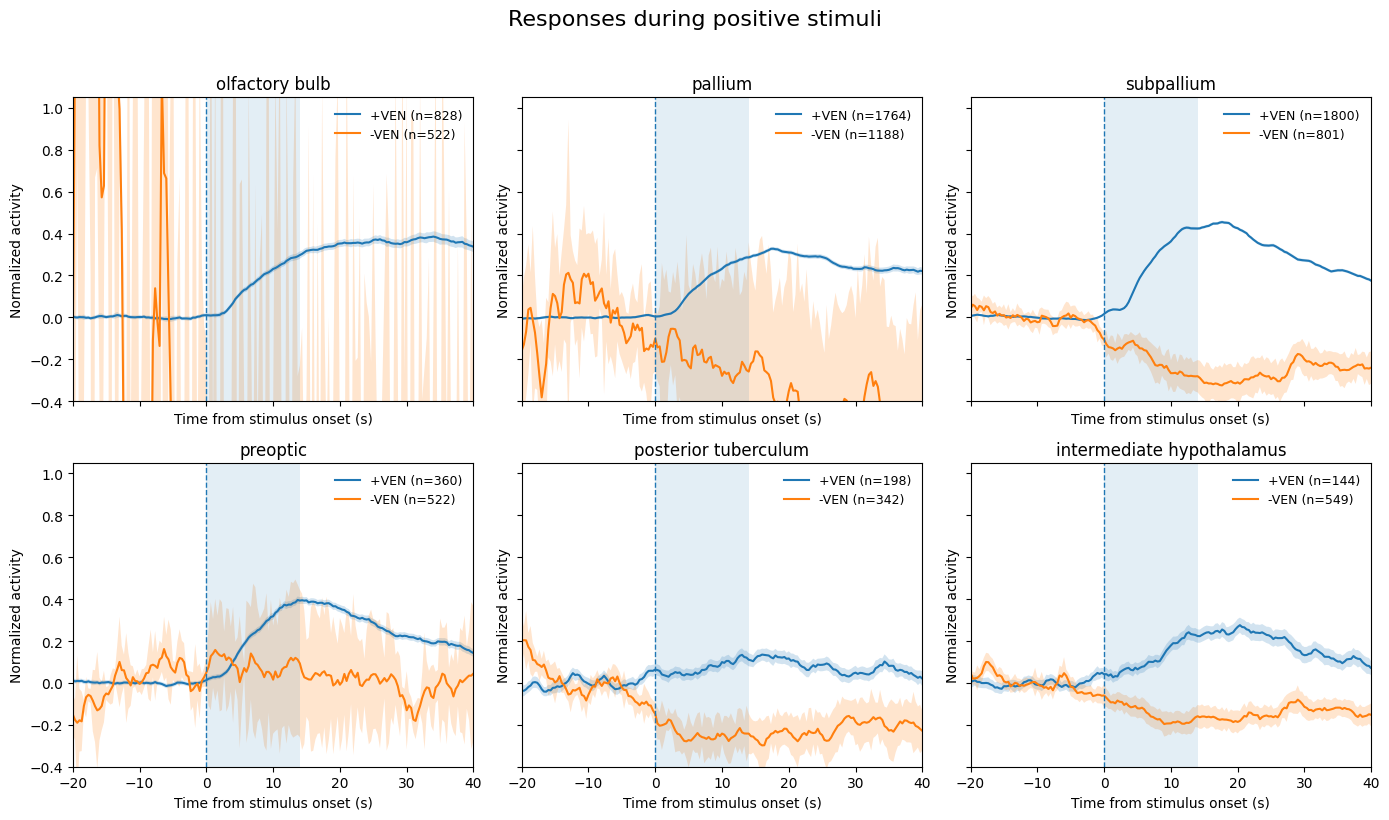

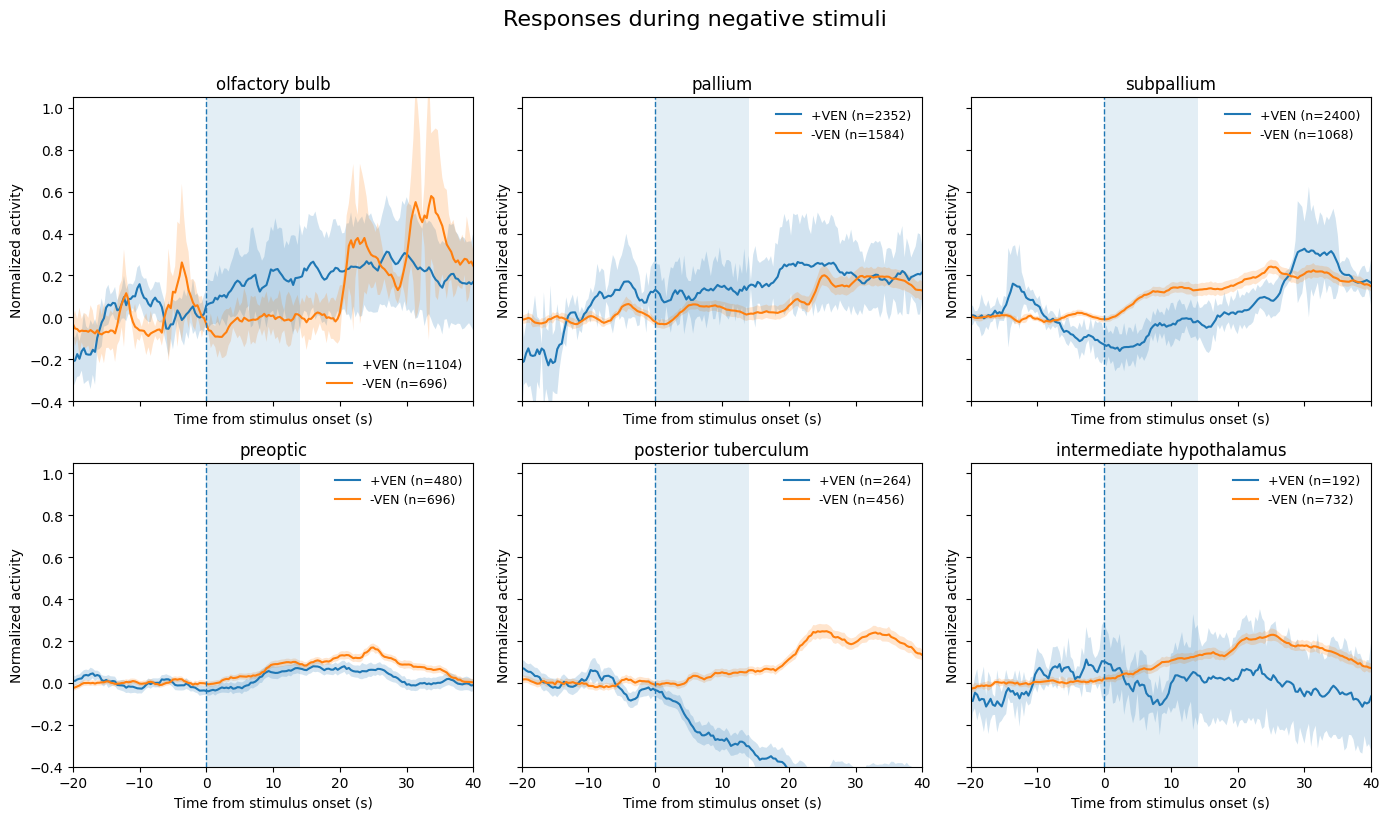

In [21]:
# convert seconds to frame indices
def sec_to_frame(sec, frame_rate, stim_onset_s):
    return int(round((stim_onset_s + sec) * frame_rate))

baseline_window = (
    sec_to_frame(baseline_window_s[0], frame_rate, stim_onset_s),
    sec_to_frame(baseline_window_s[1], frame_rate, stim_onset_s)
)

response_window = (
    sec_to_frame(response_window_s[0], frame_rate, stim_onset_s),
    sec_to_frame(response_window_s[1], frame_rate, stim_onset_s)
)

# =========================
# 2. Select VEN neurons
# =========================
pos_df = stim_fb[stim_fb['coords'].isin(pos_coords)].copy()
neg_df = stim_fb[stim_fb['coords'].isin(neg_coords)].copy()

# keep only areas of interest
pos_df = pos_df[pos_df[area_col].isin(areas_of_interest)].copy()
neg_df = neg_df[neg_df[area_col].isin(areas_of_interest)].copy()

# keep only key stimuli if you want
pos_df = pos_df[pos_df[stim_col].isin(KEY_STIMULI)].copy()
neg_df = neg_df[neg_df[stim_col].isin(KEY_STIMULI)].copy()

# =========================
# 3. Normalize traces
# =========================
def baseline_and_peak_normalize(trace, baseline_window, response_window):
    trace = np.asarray(trace, dtype=float)

    if len(trace) == 0:
        return np.array([])

    b0, b1 = baseline_window
    r0, r1 = response_window

    if b1 > len(trace) or r1 > len(trace):
        return np.full(len(trace), np.nan)

    baseline = np.nanmean(trace[b0:b1])
    trace_bs = trace - baseline

    peak = np.nanmax(trace_bs[r0:r1])

    if np.isnan(peak) or peak == 0:
        return np.full(len(trace), np.nan)

    return trace_bs / peak

pos_df['norm_trace'] = pos_df[trace_col].apply(
    lambda x: baseline_and_peak_normalize(x, baseline_window, response_window)
)
neg_df['norm_trace'] = neg_df[trace_col].apply(
    lambda x: baseline_and_peak_normalize(x, baseline_window, response_window)
)

# =========================
# 4. Helper functions
# =========================
def stack_traces(trace_series):
    traces = [np.asarray(t, dtype=float) for t in trace_series if t is not None]
    traces = [t for t in traces if len(t) > 0 and not np.all(np.isnan(t))]

    if len(traces) == 0:
        return None

    min_len = min(len(t) for t in traces)
    traces = [t[:min_len] for t in traces]

    return np.vstack(traces)

def mean_sem(traces_2d):
    mean_trace = np.nanmean(traces_2d, axis=0)
    n = np.sum(~np.isnan(traces_2d), axis=0)
    sem_trace = np.nanstd(traces_2d, axis=0) / np.sqrt(np.maximum(n, 1))
    return mean_trace, sem_trace

def smooth_trace(trace, window=5):
    return pd.Series(trace).rolling(window=window, center=True, min_periods=1).mean().to_numpy()

# =========================
# 5. Plotting function
# =========================
def plot_valence_group(pos_data, neg_data, stimuli_to_use, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, area in zip(axes, areas_of_interest):
        pos_area = pos_data[
            (pos_data[area_col] == area) &
            (pos_data[stim_col].isin(stimuli_to_use))
        ]
        neg_area = neg_data[
            (neg_data[area_col] == area) &
            (neg_data[stim_col].isin(stimuli_to_use))
        ]

        pos_traces = stack_traces(pos_area['norm_trace'])
        neg_traces = stack_traces(neg_area['norm_trace'])

        example_traces = pos_traces if pos_traces is not None else neg_traces
        if example_traces is None:
            ax.set_visible(False)
            continue

        trace_len = example_traces.shape[1]
        x = np.arange(trace_len) / frame_rate - stim_onset_s

        if pos_traces is not None:
            pos_mean, pos_sem = mean_sem(pos_traces)
            pos_mean = smooth_trace(pos_mean, window=5)
            ax.plot(x, pos_mean, label=f'+VEN (n={len(pos_area)})')
            ax.fill_between(x, pos_mean - pos_sem, pos_mean + pos_sem, alpha=0.2)

        if neg_traces is not None:
            neg_mean, neg_sem = mean_sem(neg_traces)
            neg_mean = smooth_trace(neg_mean, window=5)
            ax.plot(x, neg_mean, label=f'-VEN (n={len(neg_area)})')
            ax.fill_between(x, neg_mean - neg_sem, neg_mean + neg_sem, alpha=0.2)

        ax.axvspan(0, stim_duration_s, alpha=0.12)
        ax.axvline(0, linestyle='--', linewidth=1)

        ax.set_title(area.replace('_', ' '))
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.4, 1.05)
        ax.set_xlabel('Time from stimulus onset (s)')
        ax.set_ylabel('Normalized activity')
        ax.legend(frameon=False, fontsize=9)

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# =========================
# 6. Make separate figures
# =========================
plot_valence_group(pos_df, neg_df, POSITIVE_STIMULI, 'Responses during positive stimuli')
plot_valence_group(pos_df, neg_df, NEGATIVE_STIMULI, 'Responses during negative stimuli')

## 7. Grand Average Population Traces

Population-level averaged responses with stimulus period overlay.

In [ ]:
def plot_grand_average(traces_dict, color_map, label_map,
                      stimulus_start=STIMULUS_START_TIME,
                      stimulus_end=STIMULUS_END_TIME,
                      smoothing_sigma=SMOOTHING_SIGMA,
                      sampling_freq=SAMPLING_FREQUENCY,
                      save_path=None):
    """Plot grand average with full timecourse and stimulus shading.
    
    Args:
        traces_dict: Dictionary with 'mean' and 'sem' for each stimulus
        color_map: Dictionary mapping stimulus to color
        label_map: Dictionary mapping stimulus to label
        stimulus_start: Stimulus start time (seconds)
        stimulus_end: Stimulus end time (seconds)
        smoothing_sigma: Gaussian smoothing parameter
        sampling_freq: Sampling frequency (Hz)
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    time_interval = 1 / sampling_freq
    
    fig = plt.figure(figsize=(8, 6))
    
    for stimulus in traces_dict['mean'].keys():
        mean_trace = np.array(traces_dict['mean'][stimulus])
        sem_trace = np.array(traces_dict['sem'][stimulus])
        
        # Create time array
        trace_length = len(mean_trace)
        time_seconds = np.arange(0, trace_length * time_interval, time_interval)
        
        # Apply smoothing
        smoothed_mean = gaussian_filter1d(mean_trace, sigma=smoothing_sigma)
        smoothed_sem = gaussian_filter1d(sem_trace, sigma=smoothing_sigma)
        
        # Plot
        plt.plot(time_seconds, smoothed_mean,
                label=label_map.get(stimulus, stimulus),
                color=color_map.get(stimulus, 'gray'),
                linewidth=2)
        
        # SEM shading
        plt.fill_between(time_seconds,
                        smoothed_mean - smoothed_sem,
                        smoothed_mean + smoothed_sem,
                        color=color_map.get(stimulus, 'gray'),
                        alpha=0.3)
    
    # Add stimulus period shading
    ax = plt.gca()
    y_limits = ax.get_ylim()
    
    # Gray gradient for stimulus period
    gradient = np.zeros((256, 256, 4))
    gradient[:, :, :3] = 0.5  # Gray
    gradient[:, :128, 3] = 0.3  # Constant alpha first half
    gradient[:, 128:, 3] = np.linspace(0.3, 0, 128)  # Fade second half
    
    extent = [stimulus_start, stimulus_end, y_limits[0], y_limits[1]]
    plt.imshow(gradient, extent=extent, origin='lower', aspect='auto', zorder=-1)
    
    # Scale bar at top
    y_max = y_limits[1]
    plt.hlines(y=y_max, xmin=stimulus_start, xmax=stimulus_end,
              colors='black', linewidth=4)
    
    plt.xlabel('Time (s)', fontsize=14)
    plt.ylabel('ΔF/F', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [ ]:
# Example: Plot grand average (requires area_traces from Section 4)
# fig = plot_grand_average(area_traces, COLOR_MAP, STIMULUS_LABELS)
# plt.title('Grand Average', fontsize=14)
# plt.show()

# Uncomment to save
# save_path = FIGURE_OUTPUT_DIR + 'grand_average_traces.svg'
# fig.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

## 8. Raster Plot Visualization

Create heatmap of randomly sampled neurons with concatenated stimulus responses (paper figure).

In [ ]:
def prepare_raster_data(data, stimulus_order=RASTER_STIMULUS_ORDER,
                       start_frame=RASTER_START_FRAME,
                       response_threshold=RASTER_RESPONSE_THRESHOLD,
                       n_neurons=RASTER_N_NEURONS,
                       random_state=RASTER_RANDOM_STATE):
    """Prepare data for raster plot.
    
    Steps:
        1. Average across trials per neuron per stimulus
        2. Concatenate stimuli in order (starting from start_frame)
        3. Calculate response strength (max value)
        4. Filter neurons above threshold
        5. Random sample n_neurons
        
    Args:
        data: DataFrame with neural data
        stimulus_order: Order to concatenate stimuli
        start_frame: Start frame for each stimulus trace
        response_threshold: Minimum max response
        n_neurons: Number of neurons to sample
        random_state: Random seed
        
    Returns:
        heatmap_data: (n_neurons, total_frames) array
        stimulus_positions: list of (position, label) tuples
    """
    # Calculate average response per neuron per stimulus
    average_traces = (
        data
        .groupby(['neuron_id', 'stimulus'])['img_trace']
        .apply(lambda traces: np.mean(np.stack(traces), axis=0))
        .reset_index()
    )
    
    # Convert stimulus to categorical with desired order
    average_traces['stimulus'] = pd.Categorical(
        average_traces['stimulus'],
        categories=stimulus_order,
        ordered=True
    )
    
    # Sort by neuron and stimulus
    average_traces = average_traces.sort_values(by=['neuron_id', 'stimulus'])
    
    # Concatenate traces for each neuron
    concatenated_averages = (
        average_traces
        .groupby('neuron_id')
        .apply(lambda df: np.concatenate([
            trace[start_frame:] 
            for trace in df.sort_values('stimulus')['img_trace']
        ]))
        .reset_index(name='img_trace')
    )
    
    # Calculate response strength
    concatenated_averages['response_strength'] = \
        concatenated_averages['img_trace'].apply(lambda trace: np.max(trace))
    
    # Filter by threshold
    filtered_neurons = concatenated_averages[
        concatenated_averages['response_strength'] > response_threshold
    ]
    
    print(f"Neurons above threshold: {len(filtered_neurons)}")
    
    # Random sample
    if len(filtered_neurons) >= n_neurons:
        random_sample = filtered_neurons.sample(n=n_neurons, random_state=random_state)
    else:
        print(f"Warning: Only {len(filtered_neurons)} neurons available, using all")
        random_sample = filtered_neurons
    
    # Create heatmap data
    heatmap_data = np.vstack(random_sample['img_trace'].to_numpy())
    
    # Calculate stimulus positions for labeling
    stimulus_positions = []
    current_position = 0
    
    for stim in stimulus_order:
        stim_traces = average_traces[average_traces['stimulus'] == stim]['img_trace']
        if len(stim_traces) > 0:
            stim_length = len(stim_traces.iloc[0][start_frame:])
            label_position = current_position + stim_length // 2
            stimulus_positions.append((label_position, stim))
            current_position += stim_length
    
    return heatmap_data, stimulus_positions

In [ ]:
def plot_raster_heatmap(heatmap_data, stimulus_positions, label_map,
                        vmin=-5, vmax=None, cmap='rainbow',
                        frame_marker_interval=240, save_path=None):
    """Create raster plot heatmap.
    
    Args:
        heatmap_data: (n_neurons, total_frames) array
        stimulus_positions: list of (position, label) tuples
        label_map: Dictionary mapping stimulus to display label
        vmin: Minimum value for colormap normalization
        vmax: Maximum value (None = use data max)
        cmap: Colormap name
        frame_marker_interval: Add vertical lines every N frames
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    if vmax is None:
        vmax = heatmap_data.max()
    
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    
    fig = plt.figure(figsize=(8, 6))
    plt.imshow(heatmap_data, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
    
    # Add stimulus labels at top
    for pos, stim in stimulus_positions:
        plt.text(pos, heatmap_data.shape[0] - 103,
                label_map.get(stim, stim),
                fontsize=20, ha='center', color='black')
    
    # Add frame markers
    for x in range(0, heatmap_data.shape[1], frame_marker_interval):
        plt.axvline(x=x, color='white', linestyle='--', linewidth=2)
    
    plt.xlabel('Time (frames)', fontsize=14)
    plt.ylabel('Neuron', fontsize=14)
    plt.title(f'Raster Plot (n={heatmap_data.shape[0]})', fontsize=16)
    
    plt.colorbar(label='ΔF/F', shrink=0.8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [ ]:
# Generate raster plot
# Note: This works best with whole-brain data (stim_dff)

# Prepare data
# heatmap_data, stim_positions = prepare_raster_data(stim_dff)

# Create plot
# fig = plot_raster_heatmap(heatmap_data, stim_positions, STIMULUS_LABELS)
# plt.show()

# Uncomment to save
# save_path = FIGURE_OUTPUT_DIR + 'wholebrain_raster.svg'
# fig.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

## 9. PCA Trajectory Analysis

Analyze neural population dynamics using Principal Component Analysis.

In [ ]:
def prepare_pca_data(data, stimuli=KEY_STIMULI):
    """Prepare data array for PCA.
    
    Args:
        data: DataFrame with neural data
        stimuli: List of stimuli to include
        
    Returns:
        data_array: (n_stimuli, n_neurons, n_frames) array
        unique_neurons: List of neuron IDs
    """
    # Calculate average traces per neuron per stimulus
    average_traces = (
        data
        .groupby(['neuron_id', 'stimulus'])['img_trace']
        .apply(lambda traces: np.mean(np.stack(traces), axis=0))
        .reset_index()
    )
    
    unique_neurons = average_traces['neuron_id'].unique()
    num_neurons = len(unique_neurons)
    num_stimuli = len(stimuli)
    num_frames = len(average_traces['img_trace'].iloc[0])
    
    # Initialize array
    data_array = np.zeros((num_stimuli, num_neurons, num_frames))
    
    # Create neuron index map
    neuron_index_map = {neuron: idx for idx, neuron in enumerate(unique_neurons)}
    
    # Fill array
    for i, stim in enumerate(stimuli):
        stim_data = average_traces[average_traces['stimulus'] == stim]
        for _, row in stim_data.iterrows():
            neuron_idx = neuron_index_map[row['neuron_id']]
            data_array[i, neuron_idx, :] = row['img_trace']
    
    print(f"PCA data shape: {data_array.shape}")
    print(f"(stimuli, neurons, frames)")
    
    return data_array, unique_neurons

In [ ]:
def compute_pca(data_array, n_components=PCA_N_COMPONENTS,
                smoothing_sigma=PCA_SMOOTHING_SIGMA):
    """Fit PCA and smooth trajectories.
    
    Args:
        data_array: (n_stimuli, n_neurons, n_frames) array
        n_components: Number of PCs to compute
        smoothing_sigma: Gaussian smoothing for PC trajectories
        
    Returns:
        smoothed_pca_data: (n_stimuli, n_frames, n_components) array
        explained_variance: Array of variance explained per PC
        pca: Fitted PCA object
    """
    num_stimuli, num_neurons, num_frames = data_array.shape
    
    # Reshape for PCA: (stimuli * frames, neurons)
    reshaped_data = data_array.reshape(num_stimuli * num_frames, num_neurons)
    
    # Fit PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(reshaped_data)
    
    # Reshape back: (stimuli, frames, components)
    pca_data = pca_result.reshape(num_stimuli, num_frames, n_components)
    
    # Smooth each PC trajectory
    smoothed_pca_data = np.zeros_like(pca_data)
    for i in range(num_stimuli):
        for j in range(n_components):
            smoothed_pca_data[i, :, j] = gaussian_filter1d(
                pca_data[i, :, j],
                sigma=smoothing_sigma
            )
    
    explained_variance = pca.explained_variance_ratio_ * 100
    
    print(f"\nExplained variance by PC:")
    for i, var in enumerate(explained_variance[:5]):
        print(f"  PC{i+1}: {var:.2f}%")
    
    return smoothed_pca_data, explained_variance, pca

In [ ]:
def plot_pca_2d_panels(pca_data, explained_var, stimuli, colors, label_map,
                       pc_pairs=[(0,1), (1,2), (2,3)], save_path=None):
    """Plot multiple PC pairs in subplots.
    
    Args:
        pca_data: (n_stimuli, n_frames, n_components) array
        explained_var: Array of variance explained per PC
        stimuli: List of stimulus names
        colors: List of colors for each stimulus
        label_map: Dictionary mapping stimulus to label
        pc_pairs: List of (pc_x, pc_y) tuples to plot
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    num_plots = len(pc_pairs)
    fig, axes = plt.subplots(1, num_plots, figsize=(20, 6), sharey=False)
    
    if num_plots == 1:
        axes = [axes]
    
    for idx, (pc_x, pc_y) in enumerate(pc_pairs):
        ax = axes[idx]
        
        for i, stimulus in enumerate(stimuli):
            pc_x_data = pca_data[i, :, pc_x]
            pc_y_data = pca_data[i, :, pc_y]
            
            ax.plot(pc_x_data, pc_y_data,
                   label=label_map.get(stimulus, stimulus) if idx == 0 else None,
                   color=colors[i], linewidth=6)
        
        ax.set_xlabel(f'PC{pc_x + 1} ({explained_var[pc_x]:.2f}% Var. expl.)', fontsize=28)
        ax.set_ylabel(f'PC{pc_y + 1} ({explained_var[pc_y]:.2f}% Var. expl.)', fontsize=28)
        ax.tick_params(axis='both', labelsize=24)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Add legend to first subplot
    axes[0].legend(loc='best', fontsize=20)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [ ]:
def plot_pca_2d_single(pca_data, explained_var, stimuli, colors, label_map,
                      pc_x=1, pc_y=2, save_path=None):
    """Plot single PC pair.
    
    Args:
        pca_data: (n_stimuli, n_frames, n_components) array
        explained_var: Array of variance explained per PC
        stimuli: List of stimulus names
        colors: List of colors for each stimulus
        label_map: Dictionary mapping stimulus to label
        pc_x, pc_y: PC indices to plot
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    fig = plt.figure(figsize=(5, 4))
    
    for i in range(len(stimuli)):
        pc_x_data = pca_data[i, :, pc_x]
        pc_y_data = pca_data[i, :, pc_y]
        
        plt.plot(pc_x_data, pc_y_data,
                label=label_map.get(stimuli[i], stimuli[i]),
                color=colors[i])
    
    plt.xlabel(f'PC{pc_x + 1} ({explained_var[pc_x]:.2f}% variance explained)', fontsize=12)
    plt.ylabel(f'PC{pc_y + 1} ({explained_var[pc_y]:.2f}% variance explained)', fontsize=12)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [ ]:
def plot_pca_3d(pca_data, explained_var, stimuli, colors, label_map, save_path=None):
    """Plot 3D PCA trajectory (PC1, PC2, PC3).
    
    Args:
        pca_data: (n_stimuli, n_frames, n_components) array
        explained_var: Array of variance explained per PC
        stimuli: List of stimulus names
        colors: List of colors for each stimulus
        label_map: Dictionary mapping stimulus to label
        save_path: Optional path to save figure
        
    Returns:
        matplotlib.figure.Figure
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    for i in range(len(stimuli)):
        pc1 = pca_data[i, :, 0]
        pc2 = pca_data[i, :, 1]
        pc3 = pca_data[i, :, 2]
        
        ax.plot(pc1, pc2, pc3,
               label=label_map.get(stimuli[i], stimuli[i]),
               color=colors[i], linewidth=2.5)
    
    ax.set_xlabel(f'PC1 ({explained_var[0]:.2f}% variance)', fontsize=16)
    ax.set_ylabel(f'PC2 ({explained_var[1]:.2f}% variance)', fontsize=16)
    ax.set_zlabel(f'PC3 ({explained_var[2]:.2f}% variance)', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=16)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    
    return fig

In [ ]:
def plot_pca_timecourse(pca_data, explained_var, stimuli, colors, label_map,
                        n_pcs=None, save_path_prefix=None):
    """Plot each PC as a function of time.
    
    Args:
        pca_data: (n_stimuli, n_frames, n_components) array
        explained_var: Array of variance explained per PC
        stimuli: List of stimulus names
        colors: List of colors for each stimulus
        label_map: Dictionary mapping stimulus to label
        n_pcs: Number of PCs to plot (None = all)
        save_path_prefix: Optional prefix for save paths
        
    Returns:
        List of matplotlib.figure.Figure objects
    """
    num_stimuli, time_points, num_pcs_total = pca_data.shape
    
    if n_pcs is None:
        n_pcs = num_pcs_total
    
    figures = []
    
    for pc in range(n_pcs):
        fig = plt.figure(figsize=(6, 3))
        
        pc_all_stimuli = pca_data[:, :, pc]
        
        for i in range(num_stimuli):
            plt.plot(range(time_points), pc_all_stimuli[i, :],
                    label=label_map.get(stimuli[i], stimuli[i]),
                    color=colors[i])
        
        plt.title(f'PC{pc + 1} ({explained_var[pc]:.2f}% variance)', fontsize=14)
        plt.xlabel('Time (frames)', fontsize=12)
        plt.ylabel(f'PC{pc + 1} Value', fontsize=12)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
        
        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        
        if save_path_prefix:
            save_path = f"{save_path_prefix}_pc{pc+1}_timecourse.svg"
            plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
        
        figures.append(fig)
    
    return figures

In [ ]:
# Generate PCA analysis
# Note: This works best with whole-brain data (stim_dff)

# Prepare data
# pca_array, neurons = prepare_pca_data(stim_dff)

# Compute PCA
# smoothed_pca, explained_var, pca_obj = compute_pca(pca_array)

# Plot 2D panels
# fig1 = plot_pca_2d_panels(smoothed_pca, explained_var, KEY_STIMULI, STIMULUS_COLORS, STIMULUS_LABELS)
# plt.show()

# Plot single 2D
# fig2 = plot_pca_2d_single(smoothed_pca, explained_var, KEY_STIMULI, STIMULUS_COLORS, STIMULUS_LABELS)
# plt.show()

# Plot 3D
# fig3 = plot_pca_3d(smoothed_pca, explained_var, KEY_STIMULI, STIMULUS_COLORS, STIMULUS_LABELS)
# plt.show()

# Plot timecourses (first 4 PCs)
# figs = plot_pca_timecourse(smoothed_pca, explained_var, KEY_STIMULI, STIMULUS_COLORS, STIMULUS_LABELS, n_pcs=4)
# for fig in figs:
#     plt.show()

# Uncomment to save
# fig1.savefig(FIGURE_OUTPUT_DIR + 'pca_2d_panels.svg', format='svg', dpi=300, bbox_inches='tight')
# fig2.savefig(FIGURE_OUTPUT_DIR + 'pca_2d_single.svg', format='svg', dpi=300, bbox_inches='tight')
# fig3.savefig(FIGURE_OUTPUT_DIR + 'pca_3d.svg', format='svg', dpi=300, bbox_inches='tight')